# PPE Classification v6.3 — 균등 샘플링 + MobileNetV3Large
## 안전모 / 안전조끼 착용 여부 분류 (통합 모델)

### 파일명 라벨 규칙
```
파일명 형식: XXXX_HV.jpg
  0001_00.jpg → helmet=0, vest=0
  0002_10.jpg → helmet=1, vest=0
  0003_01.jpg → helmet=0, vest=1
  0004_11.jpg → helmet=1, vest=1
```

### v6.2 → v6.3 변경사항
```
1. 분리 모델(헬멧/조끼 각각) 코드 전부 제거 → 통합 모델 1개만 유지
2. 클래스별 균등 샘플링: 11/10/00 각 1000장, 01 전체(~904장)
3. 백본: EfficientNetB0 → MobileNetV3Large
```

---
## 1. 모듈 로딩

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
import os
import time
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("NumPy Version      :", np.__version__)
print("TensorFlow Version :", tf.__version__)

NumPy Version      : 2.4.4
TensorFlow Version : 2.21.0


---
## 2. 실행 환경 감지

In [4]:
try:
    import google.colab
    colab = True
    print("환경: Google Colab")
except ImportError:
    colab = False
    print("환경: 로컬 (VS Code / Jupyter)")

환경: 로컬 (VS Code / Jupyter)


---
## 3. 경로 설정
### ★ 로컬 실행 시 `LOCAL_DATA_PATH`, `LOCAL_SAVE_PATH`만 수정

In [5]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [6]:
# ============================================================
# #  ★ 로컬 실행 시 아래 두 경로를 본인 환경에 맞게 수정하세요
# ============================================================
LOCAL_DATA_PATH = r'C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\images'   # 이미지 폴더
LOCAL_SAVE_PATH = r'C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive'      # 모델 저장 폴더
# ============================================================

if colab:
    # ── Colab: Drive 마운트 후 zip 압축 해제 ──
    # from google.colab import drive
    # drive.mount('/content/drive')
    print('Google Drive 마운트 완료')

    !unzip -q -o /content/drive/MyDrive/Safe/Result.zip -d /content/
    files_path = '/content/drive/MyDrive/프로젝트/Result/Result'
    save_dir   = '/content/drive/MyDrive/프로젝트/Result/Result'
else:
    # ── 로컬: 위에서 설정한 경로 사용 ──
    files_path = LOCAL_DATA_PATH
    save_dir   = LOCAL_SAVE_PATH

os.makedirs(save_dir, exist_ok=True)

print(f"\n데이터 경로 : {files_path}")
print(f"저장 경로   : {save_dir}")

# 경로 존재 여부 확인
if not os.path.exists(files_path):
    print(f"\n⚠️  경로를 찾을 수 없어요: {files_path}")
    print("   LOCAL_DATA_PATH 를 올바르게 수정해 주세요.")
else:
    img_count = len(glob.glob(files_path + '/*.*'))
    print(f"\n✅ 경로 확인 완료  ({img_count}개 파일 발견)")


데이터 경로 : C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\images
저장 경로   : C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive

✅ 경로 확인 완료  (34494개 파일 발견)


---
## 4. 파일명 파싱 → 라벨 자동 생성

In [7]:
def parse_label_from_filename(filepath):
    """
    파일명에서 helmet / vest 라벨을 파싱한다.

    규칙: XXXX_HV.확장자
      H: 0=헬멧 미착용, 1=헬멧 착용
      V: 0=조끼 미착용, 1=조끼 착용

    Returns: [helmet, vest] 또는 파싱 실패 시 None
    """
    name = os.path.splitext(os.path.basename(filepath))[0]  # 확장자 제거

    if '_' not in name:
        print(f"[건너뜀] '_' 없는 파일명: {os.path.basename(filepath)}")
        return None

    label_str = name.split('_')[-1]  # '_' 뒤 마지막 부분

    if len(label_str) < 2:
        print(f"[건너뜀] 라벨 자리수 부족: {os.path.basename(filepath)}")
        return None

    try:
        helmet = int(label_str[0])
        vest   = int(label_str[1])
    except ValueError:
        print(f"[건너뜀] 숫자 아닌 라벨: {os.path.basename(filepath)}")
        return None

    if helmet not in (0, 1) or vest not in (0, 1):
        print(f"[건너뜀] 라벨은 0 또는 1이어야 함: {os.path.basename(filepath)}")
        return None

    return [helmet, vest]


# 파싱 테스트
test_cases = ['0001_00.jpg', '0002_10.jpg', '0003_01.jpg', '0004_11.jpg']
print("파일명 파싱 테스트")
print("-" * 40)
for tc in test_cases:
    lbl = parse_label_from_filename(tc)
    print(f"  {tc:15s} → helmet={lbl[0]}, vest={lbl[1]}")

파일명 파싱 테스트
----------------------------------------
  0001_00.jpg     → helmet=0, vest=0
  0002_10.jpg     → helmet=1, vest=0
  0003_01.jpg     → helmet=0, vest=1
  0004_11.jpg     → helmet=1, vest=1


---
## 6. 이미지 로딩 + 클래스별 균등 샘플링
> 11/10/00: 각 1000장 랜덤 추출, 01: 전체 사용 (~904장)

In [8]:
%%time
IMG_SIZE = 224
SAMPLE_PER_CLASS = 1000

all_files = sorted(
    glob.glob(files_path + '/*.jpg') +
    glob.glob(files_path + '/*.jpeg') +
    glob.glob(files_path + '/*.png')
)
print(f"전체 파일 수: {len(all_files)}개")


def resize_with_padding(img, size=224):
    h, w = img.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h))
    canvas = np.zeros((size, size, 3), dtype=np.uint8)
    top  = (size - new_h) // 2
    left = (size - new_w) // 2
    canvas[top:top+new_h, left:left+new_w] = img_resized
    return canvas


# 1단계: 클래스별 분류
class_files = {'11': [], '10': [], '01': [], '00': []}
skipped = 0
for fpath in all_files:
    lbl = parse_label_from_filename(fpath)
    if lbl is None:
        skipped += 1
        continue
    class_files[f"{int(lbl[0])}{int(lbl[1])}"].append(fpath)

print(f"파싱 완료 (건너뜀: {skipped}장)")
for k, v in class_files.items():
    print(f"  {k} (helmet={k[0]}, vest={k[1]}): {len(v)}장")

# 2단계: 균등 샘플링
random.seed(42)
sampled_files = []
print(f"\n★ 클래스별 샘플링 (목표: 각 {SAMPLE_PER_CLASS}장, 부족 시 전체)")
for key in ['11', '10', '01', '00']:
    files = class_files[key]
    selected = files if len(files) <= SAMPLE_PER_CLASS else random.sample(files, SAMPLE_PER_CLASS)
    sampled_files.extend([(f, key) for f in selected])
    print(f"  {key}: {len(files)}장 → {len(selected)}장 선택")
print(f"총 샘플: {len(sampled_files)}장")

# 3단계: 로딩
images, labels, load_fail = [], [], 0
for fpath, key in sampled_files:
    img = cv2.imread(fpath, cv2.IMREAD_COLOR)
    if img is None:
        load_fail += 1
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_with_padding(img, IMG_SIZE)
    images.append(img)
    labels.append([int(key[0]), int(key[1])])

images = np.array(images, dtype=np.uint8)
labels = np.array(labels, dtype=np.float32)
print(f"\n✅ 로딩 완료: {len(images)}장  (실패: {load_fail}장)")
print(f"images: {images.shape}  labels: {labels.shape}")

전체 파일 수: 34494개
파싱 완료 (건너뜀: 0장)
  11 (helmet=1, vest=1): 2644장
  10 (helmet=1, vest=0): 14471장
  01 (helmet=0, vest=1): 831장
  00 (helmet=0, vest=0): 16548장

★ 클래스별 샘플링 (목표: 각 1000장, 부족 시 전체)
  11: 2644장 → 1000장 선택
  10: 14471장 → 1000장 선택
  01: 831장 → 831장 선택
  00: 16548장 → 1000장 선택
총 샘플: 3831장

✅ 로딩 완료: 3831장  (실패: 0장)
images: (3831, 224, 224, 3)  labels: (3831, 2)
CPU times: total: 3.44 s
Wall time: 3.34 s


---
## 7. 클래스 분포 확인

=== 클래스 분포 ===
헬멧  착용(1):  2000장   미착용(0):  1831장
조끼  착용(1):  1831장   미착용(0):  2000장

=== 조합별 분포 ===
  helmet=0, vest=0  →   1000장
  helmet=1, vest=0  →   1000장
  helmet=0, vest=1  →    831장
  helmet=1, vest=1  →   1000장


C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\495743501.py:26: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\495743501.py:26: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\495743501.py:26: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\495743501.py:26: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\495743501.py:26: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\495743501.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from fo

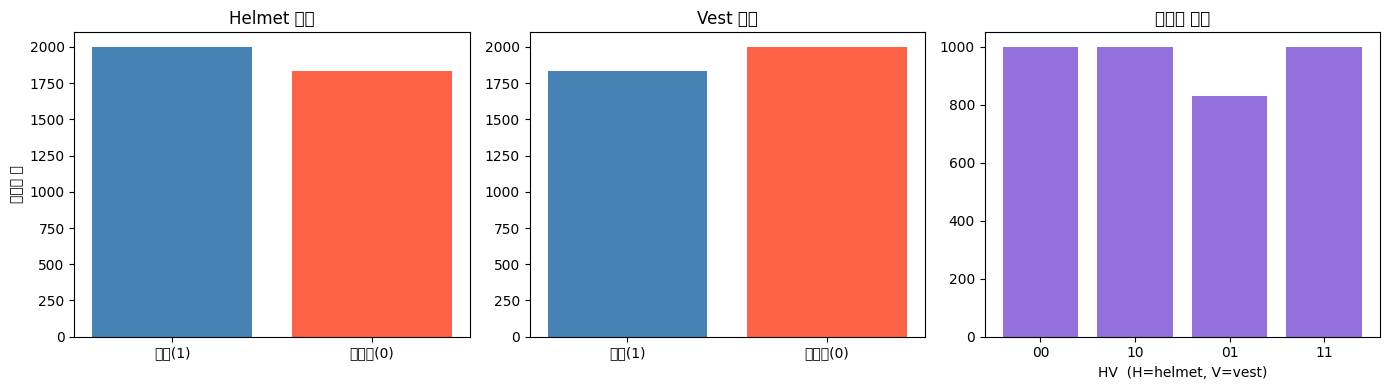

In [9]:
helmet_on  = int(labels[:, 0].sum())
helmet_off = len(labels) - helmet_on
vest_on    = int(labels[:, 1].sum())
vest_off   = len(labels) - vest_on

combos = {'00': 0, '10': 0, '01': 0, '11': 0}
for lbl in labels:
    combos[f"{int(lbl[0])}{int(lbl[1])}"] += 1

print("=== 클래스 분포 ===")
print(f"헬멧  착용(1): {helmet_on:5d}장   미착용(0): {helmet_off:5d}장")
print(f"조끼  착용(1): {vest_on  :5d}장   미착용(0): {vest_off  :5d}장")
print("\n=== 조합별 분포 ===")
for k, v in combos.items():
    print(f"  helmet={k[0]}, vest={k[1]}  →  {v:5d}장")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(['착용(1)', '미착용(0)'], [helmet_on,  helmet_off], color=['steelblue', 'tomato'])
axes[0].set_title('Helmet 분포')
axes[0].set_ylabel('이미지 수')
axes[1].bar(['착용(1)', '미착용(0)'], [vest_on,    vest_off],   color=['steelblue', 'tomato'])
axes[1].set_title('Vest 분포')
axes[2].bar(list(combos.keys()), list(combos.values()), color='mediumpurple')
axes[2].set_title('조합별 분포')
axes[2].set_xlabel('HV  (H=helmet, V=vest)')
plt.tight_layout()
plt.show()

---
## 8. Train / Test 분리

In [10]:
train_data, test_data, train_labels, test_labels = train_test_split(
    images, labels,
    test_size    = 0.2,
    random_state = 128
)
print(f"train_data   : {train_data.shape}")
print(f"train_labels : {train_labels.shape}")
print(f"test_data    : {test_data.shape}")
print(f"test_labels  : {test_labels.shape}")

train_data   : (3064, 224, 224, 3)
train_labels : (3064, 2)
test_data    : (767, 224, 224, 3)
test_labels  : (767, 2)


---
## 9. 모델 생성 — MobileNetV3Large
> 출력: sigmoid × 2 → [helmet_prob, vest_prob]

In [11]:
def build_model():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

    base_model = tf.keras.applications.MobileNetV3Large(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False
    x = base_model(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(2, activation='sigmoid', name='ppe_output')(x)

    return tf.keras.Model(inputs, outputs)

model = build_model()
print(f"모델 생성 완료  파라미터: {model.count_params():,}")
print("백본: MobileNetV3Large")
model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
모델 생성 완료  파라미터: 3,276,546
백본: MobileNetV3Large


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ppe_output (Dense)              │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,276,546 (12.50 MB)

 Trainable params: 279,682 (1.07 MB)

 Non-trainable params: 2,996,864 (11.43 MB)

---
## 10. 모델 컴파일 — Focal Loss

In [12]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['binary_accuracy']
)
print("컴파일 완료 (Binary Crossentropy)")


컴파일 완료 (Focal Loss 적용)


---
## 11. 학습 전 결과 시각화

24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 345ms/step


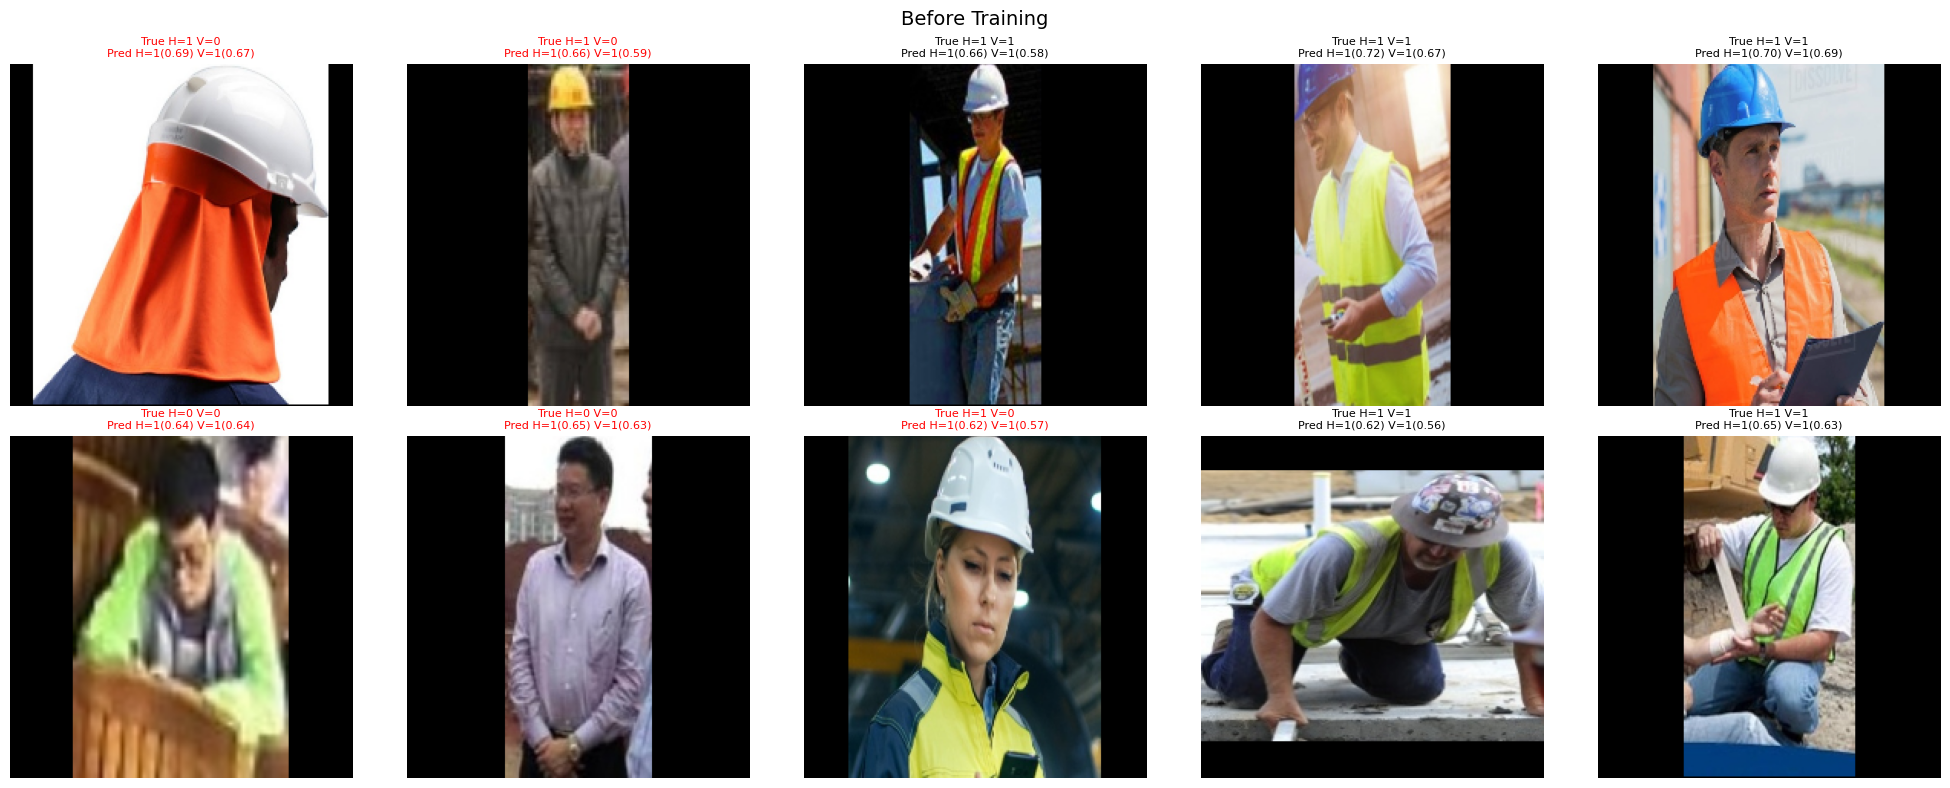

In [13]:
def Make_Result_Plot(suptitle, data, true_labels, pred_probs, n=10, threshold=0.3):
    """
    true_labels : (N, 2)  [helmet, vest]
    pred_probs  : (N, 2)  [helmet_prob, vest_prob]
    """
    size = max(len(data) // n, 1)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(suptitle, fontsize=14)
    for idx in range(n):
        cnt   = min(idx * size + size // 2, len(data) - 1)
        ax    = axes[idx // 5, idx % 5]
        ax.imshow(data[cnt])
        h_true, v_true = int(true_labels[cnt][0]), int(true_labels[cnt][1])
        h_prob, v_prob = pred_probs[cnt][0],       pred_probs[cnt][1]
        h_pred = int(h_prob >= threshold)
        v_pred = int(v_prob >= threshold)
        color  = 'red' if (h_true != h_pred or v_true != v_pred) else 'black'
        ax.set_title(
            f"True H={h_true} V={v_true}\nPred H={h_pred}({h_prob:.2f}) V={v_pred}({v_prob:.2f})",
            fontsize=8, color=color
        )
        ax.axis('off')
    plt.tight_layout()
    plt.show()

y_out = model.predict(test_data)
Make_Result_Plot("Before Training", test_data, test_labels, y_out)

---
## 12. 콜백 설정

In [14]:
saved_model_name = os.path.join(save_dir, 'PPE_MobileNetV3Large.keras')

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        saved_model_name, save_best_only=True,
        monitor='val_binary_accuracy', mode='max', verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience             = 10,
        monitor              = 'val_binary_accuracy',
        restore_best_weights = True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, verbose=1
    )
]
print(f"모델 저장 경로: {saved_model_name}")

모델 저장 경로: C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\PPE_MobileNetV3Large.keras


---
## 13. 모델 학습
> 클래스 가중치 + Focal Loss

In [15]:
%%time

history = model.fit(
    train_data, train_labels,
    epochs          = 30,
    batch_size      = 32,
    callbacks       = callbacks,
    validation_data = (test_data, test_labels)
)


헬멧 가중치: 미착용=1.04, 착용=0.97
조끼  가중치: 미착용=0.95, 착용=1.05

샘플 가중치 범위: 0.96 ~ 1.04
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - binary_accuracy: 0.5281 - loss: 0.0763
Epoch 1: val_binary_accuracy improved from None to 0.55606, saving model to C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\PPE_MobileNetV3Large.keras

Epoch 1: finished saving model to C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\PPE_MobileNetV3Large.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 43s 399ms/step - binary_accuracy: 0.5395 - loss: 0.0701 - val_binary_accuracy: 0.5561 - val_loss: 0.0433 - learning_rate: 1.0000e-04
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - binary_accuracy: 0.5795 - loss: 0.0602
Epoch 2: val_binary_accuracy improved from 0.55606 to 0.61604, saving model to C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\PPE_MobileNetV3Large.keras

Epoch 2: finished saving model to C:\Users\KCCISTC\Desktop\cropped_data_archive\cropped_data_archive\PPE

---
## 14. 학습 곡선

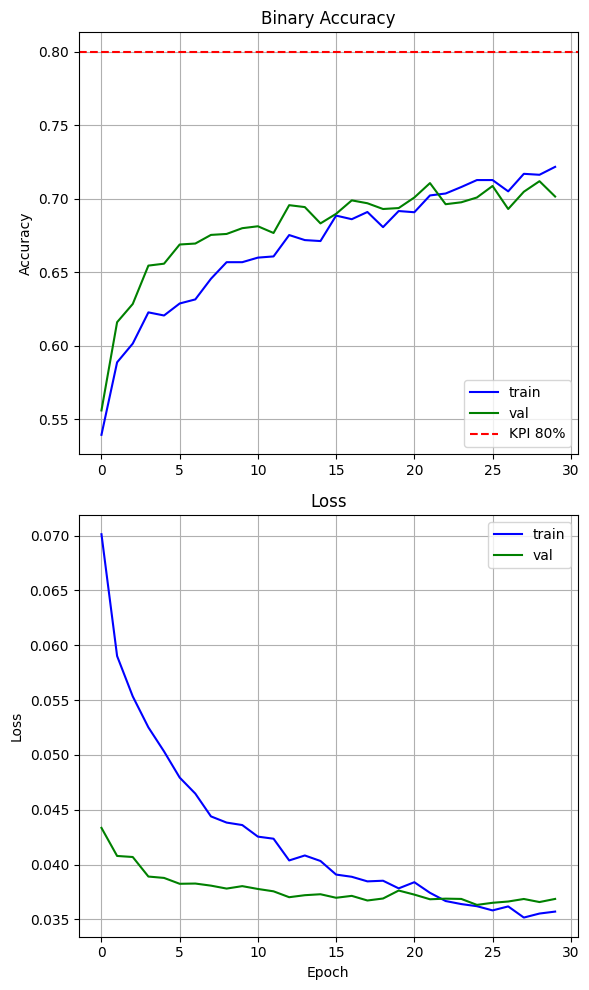

In [16]:
plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.title('Binary Accuracy')
plt.plot(history.history['binary_accuracy'],     'b', label='train')
plt.plot(history.history['val_binary_accuracy'], 'g', label='val')
plt.axhline(0.80, color='r', linestyle='--', label='KPI 80%')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'],     'b', label='train')
plt.plot(history.history['val_loss'], 'g', label='val')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

---
## 15. Best 모델 로딩 & 결과 시각화

24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 335ms/step


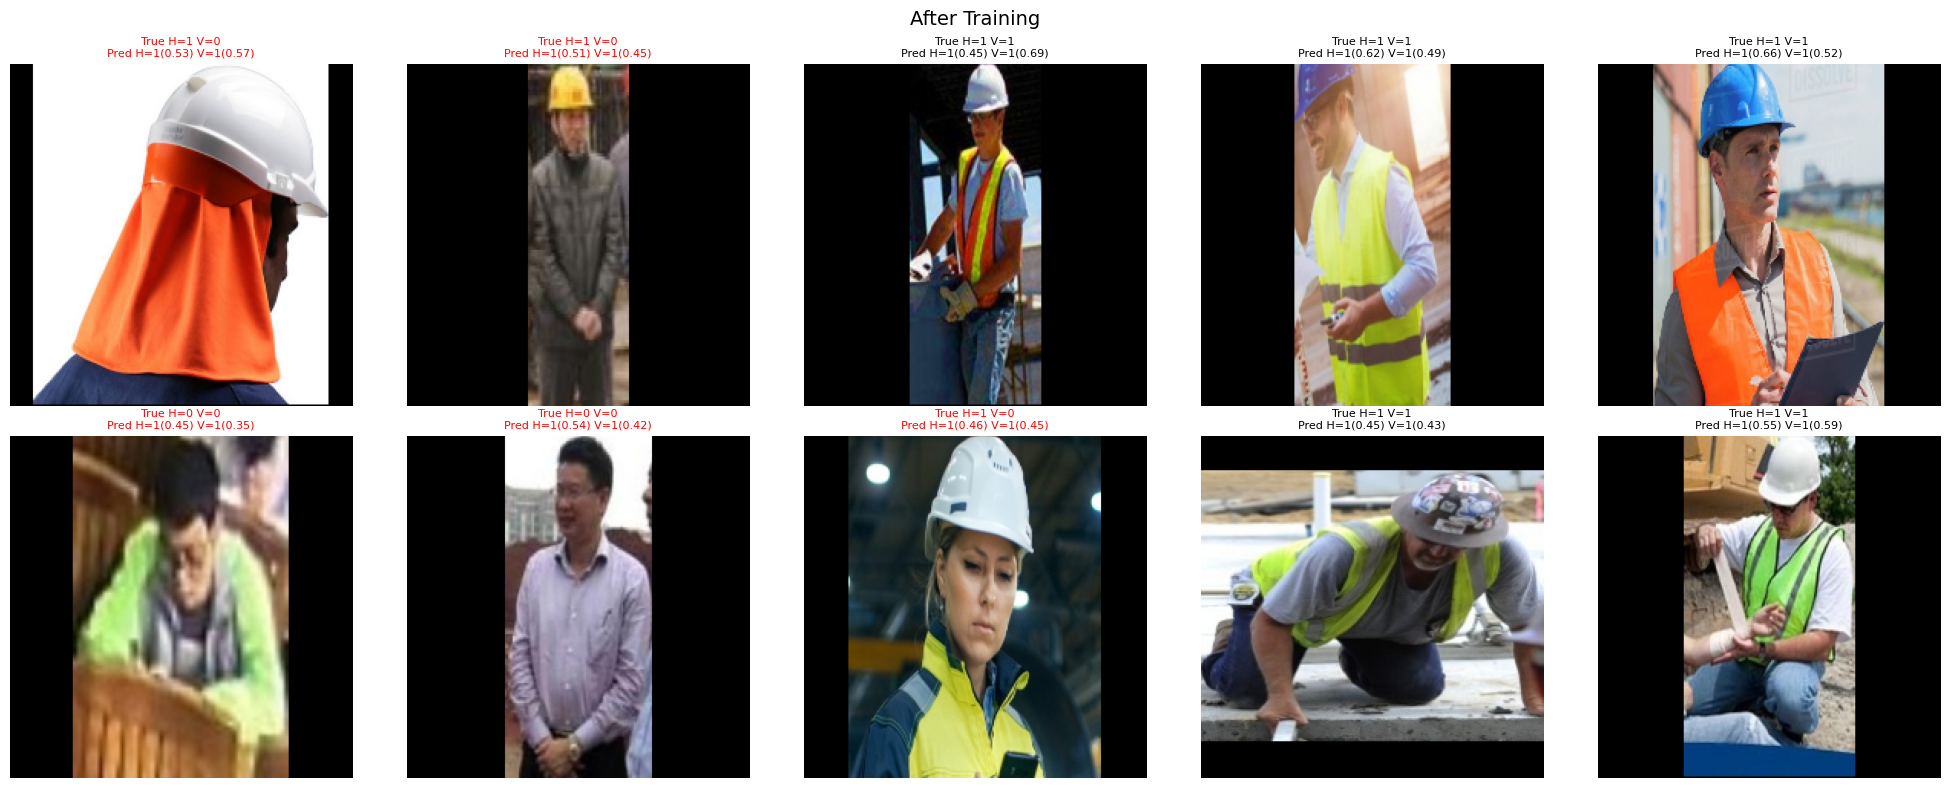

In [18]:
model_best = tf.keras.models.load_model(
    saved_model_name,
)
y_out = model_best.predict(test_data)
Make_Result_Plot("After Training", test_data, test_labels, y_out)

---
## 16. 혼동행렬 & KPI 확인

24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step


C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\2679372090.py:22: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\2679372090.py:22: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Local\Temp\ipykernel_4956\2679372090.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\KCCISTC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\KCCISTC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\KCCISTC\AppData\Roa

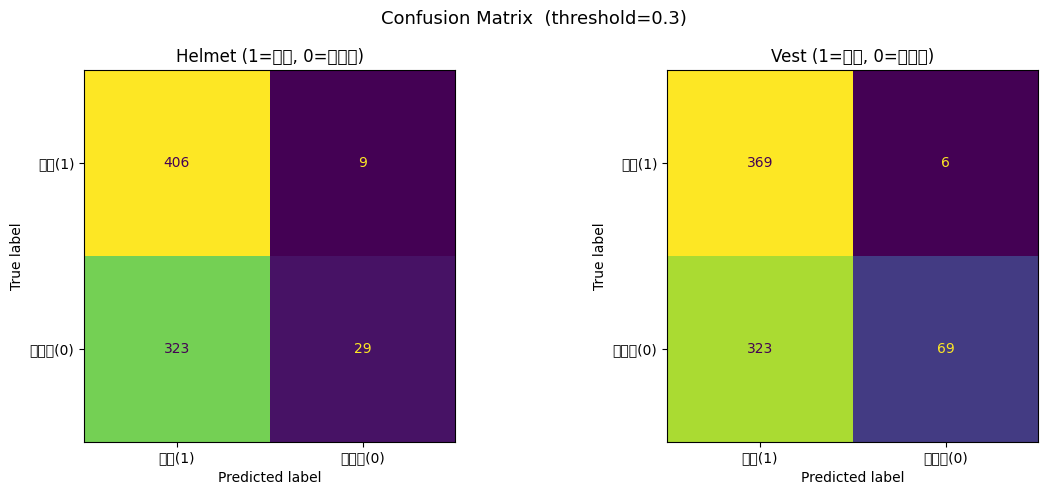

헬멧 정확도: 56.7%   (KPI ≥ 80%)  ❌
조끼 정확도: 57.1%   (KPI ≥ 80%)  ❌


In [19]:
THRESHOLD = 0.3

y_pred      = model_best.predict(test_data)
helmet_true = test_labels[:, 0].astype(int)
helmet_pred = (y_pred[:, 0] >= THRESHOLD).astype(int)
vest_true   = test_labels[:, 1].astype(int)
vest_pred   = (y_pred[:, 1] >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in zip(
    axes,
    [helmet_true, vest_true],
    [helmet_pred, vest_pred],
    ['Helmet (1=착용, 0=미착용)', 'Vest (1=착용, 0=미착용)']
):
    cm   = confusion_matrix(true, pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(cm, display_labels=['착용(1)', '미착용(0)'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f'Confusion Matrix  (threshold={THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.show()

h_acc = (helmet_true == helmet_pred).mean()
v_acc = (vest_true   == vest_pred).mean()
print(f"헬멧 정확도: {h_acc*100:.1f}%   (KPI ≥ 80%)  {'✅' if h_acc>=0.8 else '❌'}")
print(f"조끼 정확도: {v_acc*100:.1f}%   (KPI ≥ 80%)  {'✅' if v_acc>=0.8 else '❌'}")

---
## 17. 오답 이미지 모아보기

In [ ]:
def show_wrong_predictions(data, true_labels, pred_probs, threshold=0.3, max_show=20):
    wrong_idx = []
    for i in range(len(data)):
        h_true = int(true_labels[i][0])
        v_true = int(true_labels[i][1])
        h_pred = int(pred_probs[i][0] >= threshold)
        v_pred = int(pred_probs[i][1] >= threshold)
        if h_true != h_pred or v_true != v_pred:
            wrong_idx.append(i)

    print(f"전체 {len(data)}장 중 오답: {len(wrong_idx)}장")
    print(f"오답률: {len(wrong_idx)/len(data)*100:.1f}%")

    show_idx = wrong_idx[:max_show]
    n_cols   = 5
    n_rows   = max((len(show_idx) + n_cols - 1) // n_cols, 1)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = np.array(axes).flatten()
    fig.suptitle(f"오답 이미지 (총 {len(wrong_idx)}장 중 {len(show_idx)}장)", fontsize=14)

    for ax_idx, i in enumerate(show_idx):
        axes[ax_idx].imshow(data[i])
        h_t = int(true_labels[i][0])
        v_t = int(true_labels[i][1])
        h_p = float(pred_probs[i][0])
        v_p = float(pred_probs[i][1])
        axes[ax_idx].set_title(
            f"정답 H={h_t} V={v_t}\n예측 H={int(h_p>=threshold)}({h_p:.2f}) V={int(v_p>=threshold)}({v_p:.2f})",
            fontsize=8, color='red'
        )
        axes[ax_idx].axis('off')

    for ax_idx in range(len(show_idx), len(axes)):
        axes[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

show_wrong_predictions(test_data, test_labels, y_pred)

---
## 18. TFLite 변환
### 18-A. Float32

In [ ]:
converter    = tf.lite.TFLiteConverter.from_keras_model(model_best)
tflite_model = converter.convert()

tflite_path = os.path.join(save_dir, 'PPE_MobileNetV3Large.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite 저장: {tflite_path}")

### 18-B. INT8 양자화 (Raspberry Pi 5 최적화)

In [ ]:
calib_data = test_data[:100].astype(np.float32)

def representative_dataset():
    for img in calib_data:
        yield [img[np.newaxis, ...]]

conv_int8 = tf.lite.TFLiteConverter.from_keras_model(model_best)
conv_int8.optimizations                    = [tf.lite.Optimize.DEFAULT]
conv_int8.target_spec.supported_ops        = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_int8.inference_input_type             = tf.int8
conv_int8.inference_output_type            = tf.int8
conv_int8.representative_dataset           = representative_dataset

tflite_int8 = conv_int8.convert()
int8_path   = os.path.join(save_dir, 'PPE_MobileNetV3Large_INT8.tflite')
with open(int8_path, 'wb') as f:
    f.write(tflite_int8)
print(f"INT8 TFLite 저장: {int8_path}")

---
## 19. 로컬 PC 다운로드

In [ ]:
# ─────────────────────────────────────────────────────────
# 17. 로컬 PC로 다운로드 (드라이브에도 이미 저장되어 있음)
# ─────────────────────────────────────────────────────────
from google.colab import files

download_list = [
    'PPE_MobileNetV3Large.keras',        # keras 베스트 모델
    'PPE_MobileNetV3Large.tflite',       # Float32 TFLite
    'PPE_MobileNetV3Large_INT8.tflite',  # INT8 TFLite (Pi5용)
]

print("=" * 45)
print("📦 저장 파일 다운로드 시작")
print(f"📂 드라이브 저장 경로: {save_dir}")
print("=" * 45)

for fname in download_list:
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"⬇️  다운로드 중: {fname}  ({size_mb:.1f} MB)")
        files.download(fpath)
    else:
        print(f"⚠️  파일 없음 — 16번 셀(TFLite 변환)을 먼저 실행하세요: {fname}")

print("\n✅ 다운로드 완료! 드라이브 + 로컬 PC 양쪽에 저장됐어요.")


---
## 20. 추론 함수 (Raspberry Pi 5 복사 사용)
> `detector.py`에 그대로 붙여넣어 사용

In [ ]:
def run_ppe_inference(interpreter, img_bgr, threshold=0.3):
    """
    Parameters
    ----------
    interpreter : tf.lite.Interpreter  (allocate_tensors() 완료)
    img_bgr     : np.ndarray  OpenCV BGR 이미지
    threshold   : float  착용 판정 임계값 (기본 0.3)

    Returns
    -------
    dict {helmet, vest, helmet_prob, vest_prob}
    """
    inp_d = interpreter.get_input_details()
    out_d = interpreter.get_output_details()

    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_sized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    img_input = img_sized[np.newaxis, ...]

    interpreter.set_tensor(inp_d[0]['index'], img_input)
    interpreter.invoke()
    output = interpreter.get_tensor(out_d[0]['index'])[0]

    return {
        'helmet'      : bool(output[0] >= threshold),
        'vest'        : bool(output[1] >= threshold),
        'helmet_prob' : float(output[0]),
        'vest_prob'   : float(output[1]),
    }

# 동작 확인
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()

sample_bgr = cv2.cvtColor(test_data[0], cv2.COLOR_RGB2BGR)
result     = run_ppe_inference(interp, sample_bgr)

print("추론 결과 :", result)
print(f"실제 라벨 : helmet={int(test_labels[0][0])}, vest={int(test_labels[0][1])}")